Dataset Loaded: (200, 5)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Sample Scores:
    label            category  instability
0  autism  sensory_processing     0.189722
1  autism  sensory_processing     0.168062
2  autism  sensory_processing     0.331827
3  autism  sensory_processing     0.179768
4  autism  sensory_processing     0.402502

Category Summary:
         label                     category      mean       std
0       autism         emotional_regulation  0.220367  0.040985
1       autism           executive_function  0.203597  0.073678
2       autism             literal_thinking  0.282764  0.079181
3       autism             routine_rigidity  0.211837  0.057764
4       autism           sensory_processing  0.227072  0.083275
5       autism         social_communication  0.273197  0.067537
6       autism            special_interests  0.259128  0.068541
7   borderline      ambiguous_communication  0.240478  0.126054
8   borderline   context_dependent_routines  0.237520  0.087298
9   borderline                 mild_sensory  0.255182  0.079658
10 

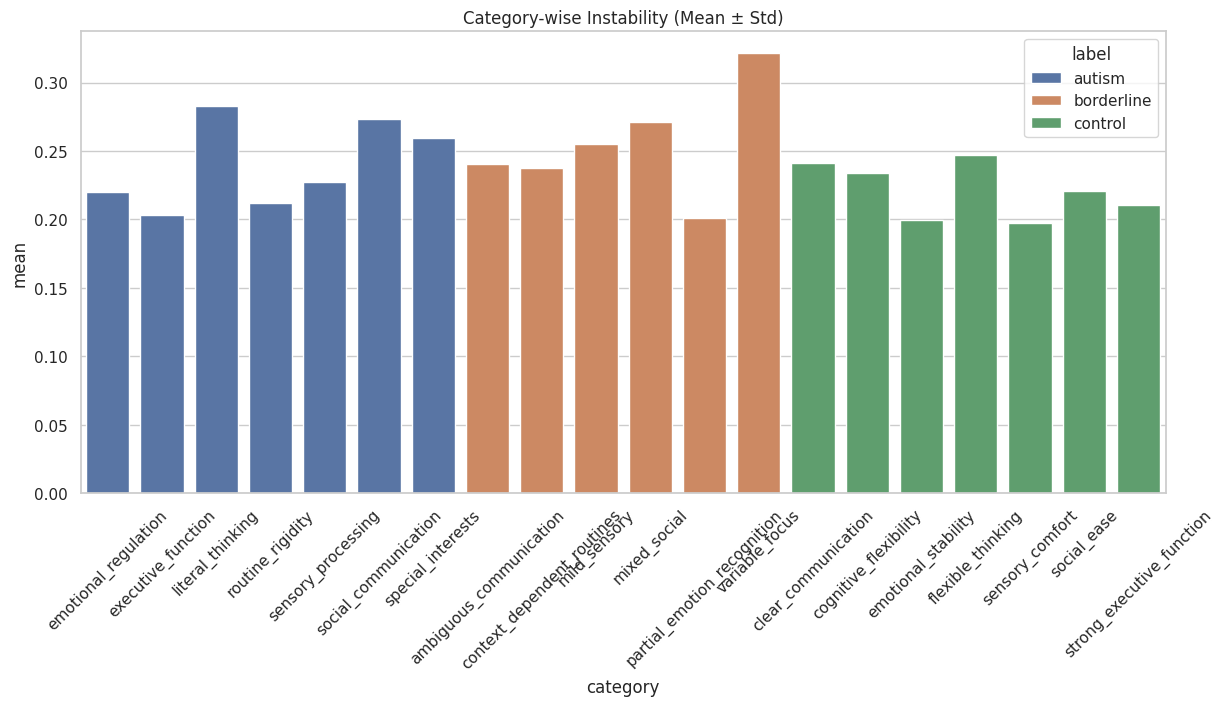

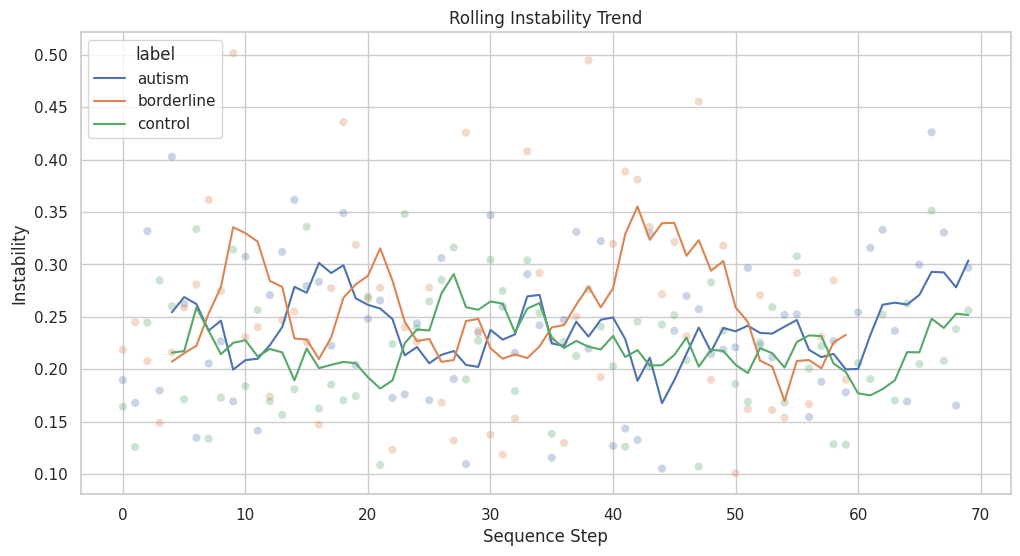

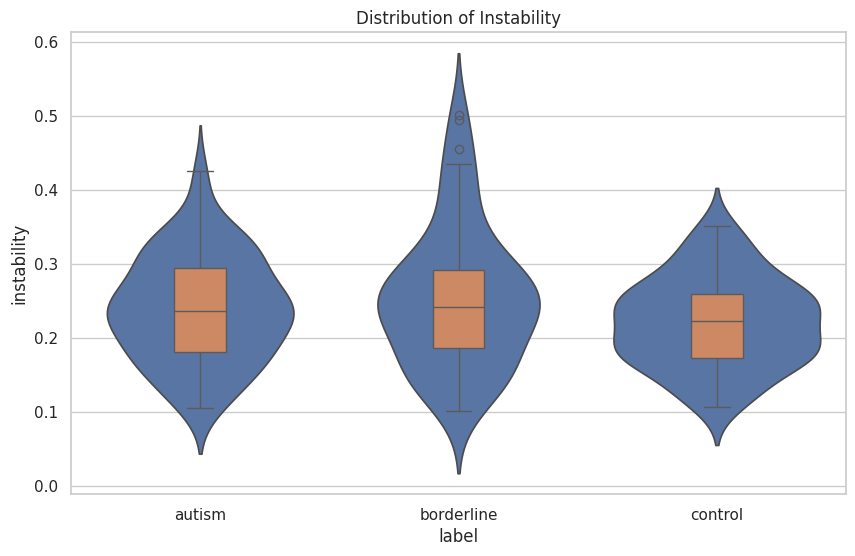

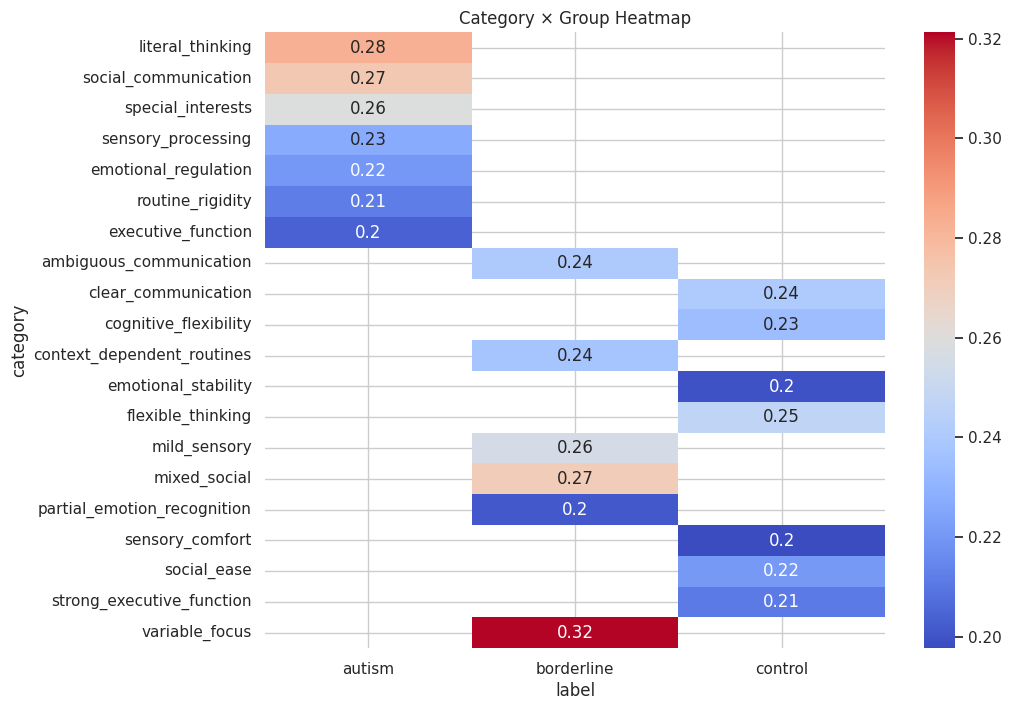

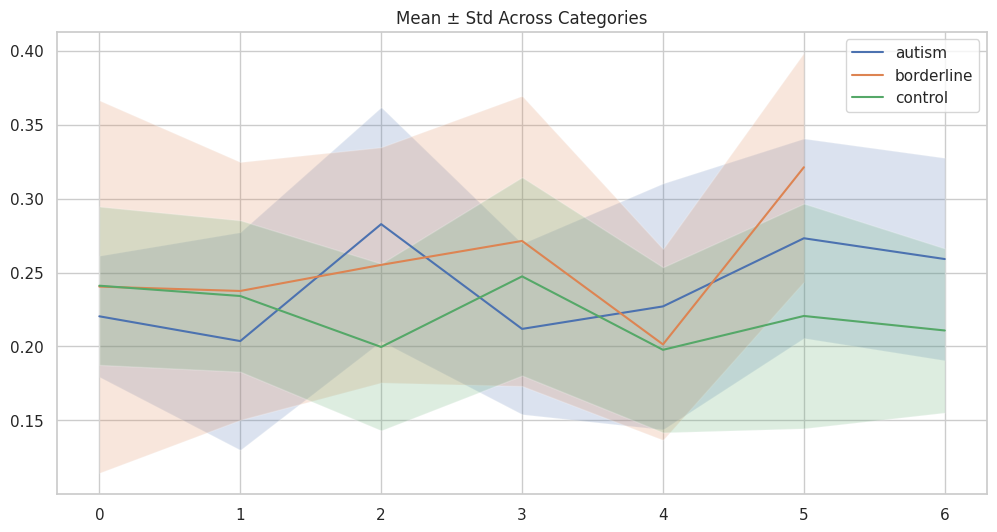


FINAL METRICS
AUTISM → Mean=0.2397, Std=0.0718
BORDERLINE → Mean=0.2545, Std=0.0946
CONTROL → Mean=0.2216, Std=0.0603

ANOVA p-value: 0.048397

Interpretation:
- Higher instability = more semantic drift
- Expected trend: Autism > Borderline > Control
- Low p-value (<0.05) ⇒ statistically significant difference


In [2]:
#Detecting Semantic Instability using Embedding Drift
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from scipy.stats import ttest_ind, f_oneway
from sentence_transformers import SentenceTransformer
sns.set(style="whitegrid")

from dataset_v2 import get_full_dataset
data = get_full_dataset()
df = pd.DataFrame(data)

print("Dataset Loaded:", df.shape)
df.head()

model = SentenceTransformer('all-MiniLM-L6-v2')

def get_embeddings(texts):
    return model.encode(texts, normalize_embeddings=True)

def compute_similarity(base_emb, variant_embs):
    return [1 - cosine(base_emb, v) for v in variant_embs]

def instability_score(similarities):
    return 1 - np.mean(similarities)

instability_list = []

for _, row in df.iterrows():
    base = row["sentence"]
    variants = row["variants"]

    emb_base = get_embeddings([base])[0]
    emb_vars = get_embeddings(variants)

    sims = compute_similarity(emb_base, emb_vars)
    score = instability_score(sims)

    instability_list.append(score)

df["instability"] = instability_list

print("\nSample Scores:")
print(df[["label", "category", "instability"]].head())

category_summary = (
    df.groupby(["label", "category"])["instability"]
    .agg(["mean", "std"])
    .reset_index()
)

print("\nCategory Summary:")
print(category_summary)

def rolling_trend(df, window=5):
    out = []
    for label in df["label"].unique():
        temp = df[df["label"] == label].reset_index(drop=True)

        temp["rolling"] = temp["instability"].rolling(window=window).mean()
        temp["step"] = np.arange(len(temp))

        out.append(temp)

    return pd.concat(out, ignore_index=True)

trend_df = rolling_trend(df, window=5)

groups = {
    label: df[df["label"] == label]["instability"].values
    for label in df["label"].unique()
}

print("\nPairwise T-Tests:")
labels = list(groups.keys())
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        t, p = ttest_ind(groups[labels[i]], groups[labels[j]])
        print(f"{labels[i]} vs {labels[j]} → t={t:.3f}, p={p:.6f}")

anova = f_oneway(*groups.values())
print(f"\nANOVA → F={anova.statistic:.3f}, p={anova.pvalue:.6f}")


# ---- 1. Category Bar ----
plt.figure(figsize=(14,6))
sns.barplot(data=category_summary, x="category", y="mean", hue="label", capsize=0.2)
plt.xticks(rotation=45)
plt.title("Category-wise Instability (Mean ± Std)")
plt.show()

# ---- 2. Rolling Trend ----
plt.figure(figsize=(12,6))

sns.lineplot(data=trend_df, x="step", y="rolling", hue="label")
sns.scatterplot(data=trend_df, x="step", y="instability", hue="label", alpha=0.3, legend=False)

plt.title("Rolling Instability Trend")
plt.xlabel("Sequence Step")
plt.ylabel("Instability")
plt.show()

# ---- 3. Violin + Box ----
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="label", y="instability", inner=None)
sns.boxplot(data=df, x="label", y="instability", width=0.2)
plt.title("Distribution of Instability")
plt.show()

# ---- 4. Heatmap ----
pivot = category_summary.pivot(index="category", columns="label", values="mean")

# sort by autism instability
pivot = pivot.sort_values(by="autism", ascending=False)

plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Category × Group Heatmap")
plt.show()

# ---- 5. Mean ± Std Band ----
plt.figure(figsize=(12,6))

for label in df["label"].unique():
    temp = category_summary[category_summary["label"] == label]
    x = range(len(temp))
    mean = temp["mean"].values
    std = temp["std"].values

    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean-std, mean+std, alpha=0.2)

plt.title("Mean ± Std Across Categories")
plt.legend()
plt.show()

print("\n==============================")
print("FINAL METRICS")
print("==============================")

for label in df["label"].unique():
    vals = df[df["label"] == label]["instability"]
    print(f"{label.upper()} → Mean={vals.mean():.4f}, Std={vals.std():.4f}")

print(f"\nANOVA p-value: {anova.pvalue:.6f}")

print("\nInterpretation:")
print("- Higher instability = more semantic drift")
print("- Expected trend: Autism > Borderline > Control")
print("- Low p-value (<0.05) ⇒ statistically significant difference")
